In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pyresample
import pyproj

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=300, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=300,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")


 
def build_storm_centered_dataset(
    ds,
    half_size=500,
    dxy=2.0,
    kind="nearest"
):
    """
    Construit un dataset centré cyclone sur grille régulière [-500, 500] km.

    Returns
    -------
    xr.Dataset
    """

    ir = ds["brightness_temperature"].values
    ir_lon = ((ds["longitude"].values+180)%360)-180
    ir_lat = ds["latitude"].values
    center_lat = ds["storm_latitude"].values[0]
    center_lon = ((ds["storm_longitude"][0].values + 180)%360)-180

    nx = ny = int(2 * half_size / dxy) + 1

    x = np.linspace(-half_size, half_size, nx)
    y = np.linspace(half_size, -half_size, ny)  # nord en haut

    proj = pyproj.Proj(              #place le cyclone au centre (0,0), et je mesure tout en km autou
        proj="aeqd",
        lat_0=center_lat,
        lon_0=center_lon,
        ellps="WGS84",
        units="km"
    )


    longitude, latitude = pyresample.utils.check_and_wrap(ir_lon, ir_lat)
    lon2d, lat2d = np.meshgrid(longitude, latitude)

    swath_ir = pyresample.SwathDefinition(
        lon2d,
        lat2d
    )

    area_def = pyresample.geometry.AreaDefinition(
        "storm",
        "storm centered grid",
        "storm",
        proj.srs,
        nx,
        ny,
        (x[0] - dxy/2, y[-1] - dxy/2, x[-1] + dxy/2, y[0] + dxy/2)
    )

    if kind == "nearest":
        ir_grid = pyresample.kd_tree.resample_nearest(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            fill_value=np.nan
        )
    else:
        ir_grid = pyresample.kd_tree.resample_gauss(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            sigmas=25000
        )

   

    ds["ir_aeqd"] = xr.DataArray(
            ir_grid,
            dims=("y", "x"),
            coords={
                "x": x,
                "y": y,
            },
            attrs={
                "units": ds["brightness_temperature"].attrs.get("units", ""),
                "description": "Brightness temperature projected onto storm-centered AEQD grid",
            },
        )

    ds["center_lat"] = center_lat
    ds["center_lon"] = center_lon

    return ds

In [2]:
import os
os.chdir("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR")
os.getcwd()

'/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR'

In [8]:
import pandas as pd
dataset_l2_irar = pd.read_csv("csv_data/IRAR_L2_dataset.csv")
irar = pd.read_csv("/scale/user/mtannaou/alternance/mnt/csvs_finaux/IRAR.csv")
len(dataset_l2_irar)

1194

In [9]:
dataset = dataset_l2_irar.copy()

## revérification des nombres de séquences valides 

In [15]:
from tqdm import tqdm;import os
from datetime import datetime, timedelta
count = 0

for itr, row in tqdm(dataset.iterrows(), total=len(dataset)):
    path_nc = row["path_irar"]
    cyclone_id = row["cyclone_id"]
    date_irar = datetime.strptime(os.path.basename(path_nc).split("_e")[-1].split("_")[0], "%Y%m%d%H%M%S")
    count_seq = 0

    for i in range(1, 6):
        date_i = date_irar + timedelta(hours=i)
        date_j = date_irar - timedelta(hours=i)
        sub_i = irar[(irar["date_irar"] == str(date_i)) & (irar["cyclone_id"] == cyclone_id)]
        sub_j = irar[(irar["date_irar"] == str(date_j)) & (irar["cyclone_id"] == cyclone_id)]

        if len(sub_i) > 0 and len(sub_j) > 0 :
            count_seq += 1 
    
    
    if count_seq == 5:
        count += 1 

    dataset.loc[itr, "valide"] = count_seq == 5

dataset_valide = dataset[dataset["valide"] == True]
len(dataset), count, len(dataset_valide)

  0%|          | 0/1194 [00:00<?, ?it/s]

100%|██████████| 1194/1194 [07:15<00:00,  2.74it/s]


(1194, 1074, 1074)

In [16]:
dataset.to_csv("csv_data/IRAR_L2_dataset.csv", index=False)

In [17]:
ind = 10   # 0 to 1074

(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)
(501, 501)


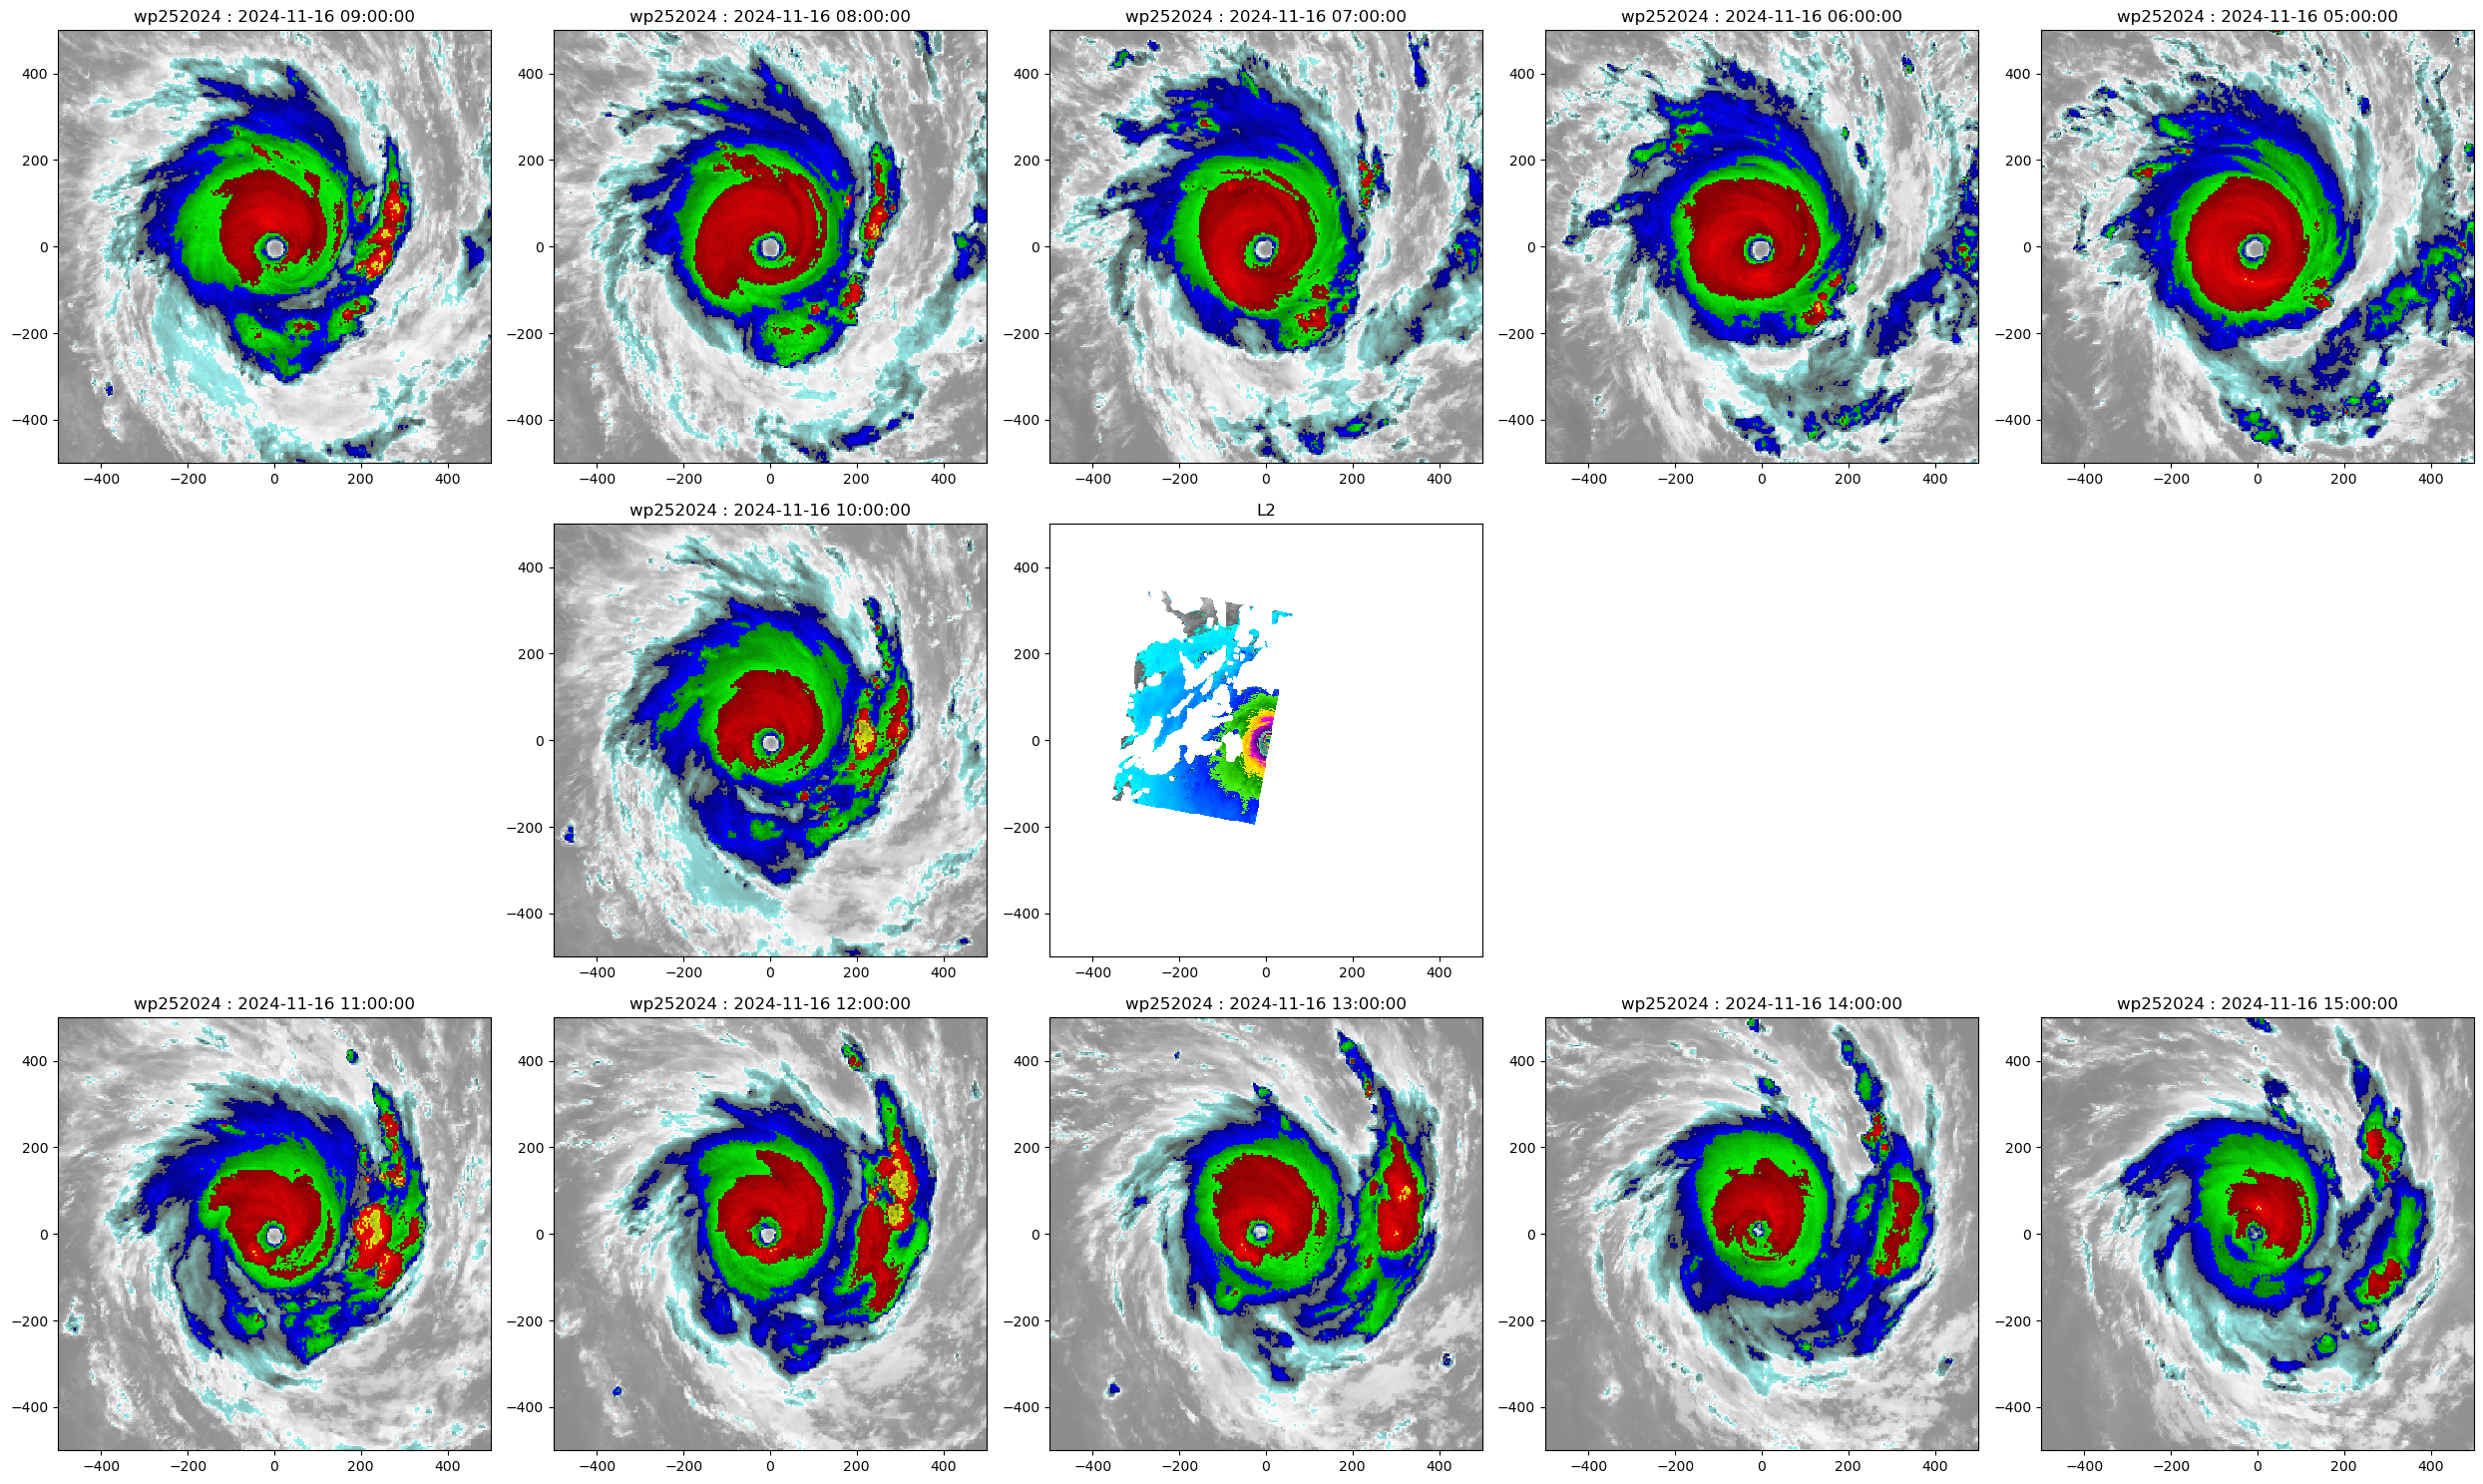

In [ ]:
from datetime import datetime, timedelta

row = dataset_valide.iloc[ind]
cyclone_id = row["cyclone_id"]
year       = row["year"]
path_irar  = row["path_irar"]
path_l2    = row["L2M path"]
date_irar  = datetime.strptime(os.path.basename(path_irar).split("_s")[-1].split("_")[0], "%Y%m%d%H%M%S")

irar["date_irar"] = pd.to_datetime(irar["date_irar"])
sequence_path_plus =  []
sequence_path_moins = []
cyclones_moins = []
cyclones_plus = []
dates_moins = []
dates_plus = []


for i in range(1,6):
    
    date_i = date_irar + timedelta(hours = i)
    date_j = date_irar - timedelta(hours = i)

    sub_i  = irar[(irar["date_irar"]==date_i) & (irar["cyclone_id"] == cyclone_id)]
    sub_j  = irar[(irar["date_irar"]==date_j) & (irar["cyclone_id"] == cyclone_id)]

    sequence_path_plus.append(sub_i["path_nc"].values[0])
    sequence_path_moins.append(sub_j["path_nc"].values[0])
    cyclones_plus.append(sub_i["cyclone_id"].values[0])
    cyclones_moins.append(sub_j["cyclone_id"].values[0])
    dates_plus.append(date_i)
    dates_moins.append(date_j)


sequence = sequence_path_moins + [path_irar] + sequence_path_plus
cyclones_id = cyclones_moins + [cyclone_id] + cyclones_plus
dates = dates_moins + [date_irar] + dates_plus

fig, axes = plt.subplots(3, 5, figsize=(25, 15))

for i, (path, cyclone_id_i, date_i) in enumerate(zip(sequence, cyclones_id, dates)):

    ds = xr.open_dataset(path)
    ds = build_storm_centered_dataset(ds)

    if "aeqd" in path:

        ir = ds["ir_aeqd"].values
        wind = ds["wind_aeqd"].values

        # IR au temps 0
        plot_ir(ir - 273.15, x_lim=500, ax=axes[1, 1])
        axes[1, 1].set_title(f"{cyclone_id} : {date_irar}")

        # SAR au temps 0
        plot_sar(wind, x_lim=500, ax=axes[1, 2])
        axes[1, 2].set_title("L2")

        axes[1,0].axis("off")
        axes[1,3].axis("off")
        axes[1,4].axis("off")


    else:
        ir = ds["ir_aeqd"].values


        if i < 5:   # t=-5H ... t=-1H
            col = i
            hour = i - 5

            plot_ir(ir - 273.15,
                    ax=axes[0, col],
                    x_lim = 500)

            axes[0, col].set_title(f"{cyclone_id_i} : {date_i}")

        elif i > 5:   # t=+1H ... t=+5H
            col = i - 6
            hour = i - 5

            plot_ir(ir - 273.15,
                    ax=axes[2, col],
                    x_lim=500)

            axes[2, col].set_title(f"{cyclone_id_i} : {date_i}")

plt.tight_layout()
plt.show()

In [45]:
for itr, row in tqdm(dataset.iterrows(), total=len(dataset), desc=f"Generating data Using IRAR Dataset : ..............."):
    
    if row["valide"] == False:
        continue
    cyclone_id = row["cyclone_id"]
    year = row["year"]
    path_irar = row["path_irar"]
    path_l2 = row["L2M path"]
    date_irar = datetime.strptime(os.path.basename(path_irar).split("_s")[-1].split("_")[0], "%Y%m%d%H%M%S")

    sequence_path_plus =  []
    sequence_path_moins = []

    for i in range(1,6):
        date_i = date_irar + timedelta(hours=i)
        date_j = date_irar - timedelta(hours=i)
        
        sub_i = irar[(irar["date_irar"]==date_i) & (irar["cyclone_id"] == cyclone_id)]
        sub_j = irar[(irar["date_irar"]==date_j) & (irar["cyclone_id"] == cyclone_id)]

        sequence_path_plus.append(sub_i["path_nc"].values[0])
        sequence_path_moins.append(sub_j["path_nc"].values[0])
    
    train_seq_paths = sequence_path_moins + [path_irar] + sequence_path_plus

    for j, path in enumerate(train_seq_paths):
        if "aeqd" in path:
            continue  # Skip already processed files
        try:
            ds = xr.open_dataset(path)
            ds = ds.where(ds != -999.0)

            ds = build_storm_centered_dataset(ds)

            tmp_path = path + ".tmp"

            ds.to_netcdf(tmp_path)

            os.replace(tmp_path, path)

            dataset.loc[itr, "ir_regrided"] = True


        except Exception as e:
            print(f"Error loading {path}: {e}")
            dataset.loc[itr, "ir_regrided"] = False
            break
    
            

Generating data Using IRAR Dataset : ...............:   3%|▎         | 33/1194 [01:45<1:07:06,  3.47s/it]

Error loading /scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2024/al182024/TC-IRAR_v02r02_AL182024_s20241110125617_e20241110125617.nc: Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)


Generating data Using IRAR Dataset : ...............:   5%|▌         | 64/1194 [03:14<1:07:58,  3.61s/it]

Error loading /scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2024/wp232024/TC-IRAR_v02r02_WP232024_s20241101005000_e20241101005000.nc: [Errno 2] No such file or directory: '/scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2024/wp232024/TC-IRAR_v02r02_WP232024_s20241101005000_e20241101005000.nc'


Generating data Using IRAR Dataset : ...............:   7%|▋         | 83/1194 [04:23<1:05:46,  3.55s/it]

...

Generating data Using IRAR Dataset : ...............:  64%|██████▍   | 766/1194 [51:20<17:50,  2.50s/it]  

Error loading /scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2021/al122021/TC-IRAR_v02r02_AL122021_s20210911124022_e20210911124022.nc: [Errno 2] No such file or directory: '/scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2021/al122021/TC-IRAR_v02r02_AL122021_s20210911124022_e20210911124022.nc'


Generating data Using IRAR Dataset : ...............:  68%|██████▊   | 812/1194 [57:47<2:26:36, 23.03s/it]

Error loading /scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2021/al042021/TC-IRAR_v02r02_AL042021_s20210629002117_e20210629002117.nc: Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)


Generating data Using IRAR Dataset : ...............: 100%|██████████| 1194/1194 [1:23:42<00:00,  4.21s/it]


In [48]:
dataset.to_csv("csv_data/IRAR_L2_dataset.csv", index=False)

In [47]:
len(dataset[dataset["ir_regrided"] == True]), len(dataset[dataset["ir_regrided"] == False])

(1058, 16)